# 🏕️ Prévision des Activités Scoutes — Séries Temporelles
## Comparaison ARIMA vs SARIMA vs Prophet

**Grille couverte :**
- ✅ Analyse de stationnarité : tests ADF + KPSS
- ✅ Décomposition : tendance / saisonnalité / résidus
- ✅ 3 Modèles : ARIMA, SARIMA, Prophet
- ✅ Évaluation : MAPE, RMSE, MAE avec analyse comparative
- ✅ Graphiques : décomposition, prédictions, comparaison des modèles

## 0. Imports & Configuration

In [24]:
import warnings
warnings.filterwarnings("ignore")

In [25]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print("✅ Prophet disponible")
except ImportError:
    try:
        from fbprophet import Prophet
        PROPHET_AVAILABLE = True
        print("✅ fbprophet disponible")
    except ImportError:
        PROPHET_AVAILABLE = False
        print("⚠️  Prophet non installé — pip install prophet")

import itertools

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
print("✅ Imports OK")

✅ Prophet disponible
✅ Imports OK


## 1. Chargement & Préparation des Données

In [26]:
FILE_PATH = "rapport1_events_augmented_from_real2.xlsx"

df_raw = pd.read_excel(FILE_PATH)
print(f"Dimensions        : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")
print(f"Colonnes          : {list(df_raw.columns)}")
print(f"Types d'événements: {df_raw['event_type'].unique()}")
print(f"Années            : {sorted(df_raw['year'].unique())}")
df_raw.head()

Dimensions        : 163 lignes × 8 colonnes
Colonnes          : ['event_name', 'event_type', 'participants', 'leaders', 'cost_TND', 'year', 'month', 'date']
Types d'événements: ['outing' 'camp']
Années            : [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


,event_name,event_type,participants,leaders,cost_TND,year,month,date
0,خرجة الربيع الكبرى – مارس 2023,outing,55,12,830,2023,3,2023-03-01
1,المخيم الصيفي للفوج – السلوم، سوسة – أوت 2025,camp,120,18,6600,2025,8,2025-08-01
2,مخيم الشتاء – المريج، عين دراهم – ديسمبر 2023,camp,70,10,2150,2023,12,2023-12-01
3,مخيم الشتاء – الناضور، بنزرت – ديسمبر 2024,camp,78,9,1910,2024,12,2024-12-01
4,خرجة كنز المدينة – المدينة العربية، تونس – مار...,outing,60,8,540,2023,3,2023-03-01


In [27]:
# ── Agrégation mensuelle ──────────────────────────────────────
df_ts = (
    df_raw
    .groupby(["year", "month"])
    .agg(
        nb_events          = ("event_name",   "count"),
        total_participants = ("participants", "sum"),
        total_leaders      = ("leaders",      "sum"),
        total_cost_TND     = ("cost_TND",     "sum"),
    )
    .reset_index()
)

df_ts["date"] = pd.to_datetime(
    df_ts["year"].astype(str) + "-" + df_ts["month"].astype(str).str.zfill(2) + "-01"
)
df_ts = df_ts.set_index("date").sort_index()

# ── Remplir les mois manquants (interpolation linéaire) ────────
full_range = pd.date_range(df_ts.index.min(), df_ts.index.max(), freq="MS")
df_ts = df_ts.reindex(full_range)
for col in ["nb_events", "total_participants", "total_leaders", "total_cost_TND"]:
    df_ts[col] = df_ts[col].interpolate(method="linear").round(1)

print(f"Série temporelle : {len(df_ts)} mois ({df_ts.index[0].date()} → {df_ts.index[-1].date()})")
df_ts.head(10)

Série temporelle : 46 mois (2023-03-01 → 2026-12-01)


,year,month,nb_events,total_participants,total_leaders,total_cost_TND
2023-03-01,2023.0,3.0,15.0,872.0,144.0,10256.0
2023-04-01,NaN,NaN,14.4,852.8,139.2,11498.1
2023-05-01,NaN,NaN,13.9,833.6,134.4,12740.2
2023-06-01,NaN,NaN,13.3,814.3,129.7,13982.3
2023-07-01,NaN,NaN,12.8,795.1,124.9,15224.4
2023-08-01,NaN,NaN,12.2,775.9,120.1,16466.6
2023-09-01,NaN,NaN,11.7,756.7,115.3,17708.7
2023-10-01,NaN,NaN,11.1,737.4,110.6,18950.8
2023-11-01,NaN,NaN,10.6,718.2,105.8,20192.9
2023-12-01,2023.0,12.0,10.0,699.0,101.0,21435.0


In [28]:
# ── Variable cible ────────────────────────────────────────────
TARGET = "total_participants"   # changer ici : nb_events | total_cost_TND
y = df_ts[TARGET].copy()

print(f"Variable cible : {TARGET}")
print(y.describe().round(2).to_string())

Variable cible : total_participants
count      46.00
mean      675.17
std       419.61
min       110.00
25%       311.08
50%       706.50
75%       852.10
max      2006.00


## 2. Analyse Exploratoire

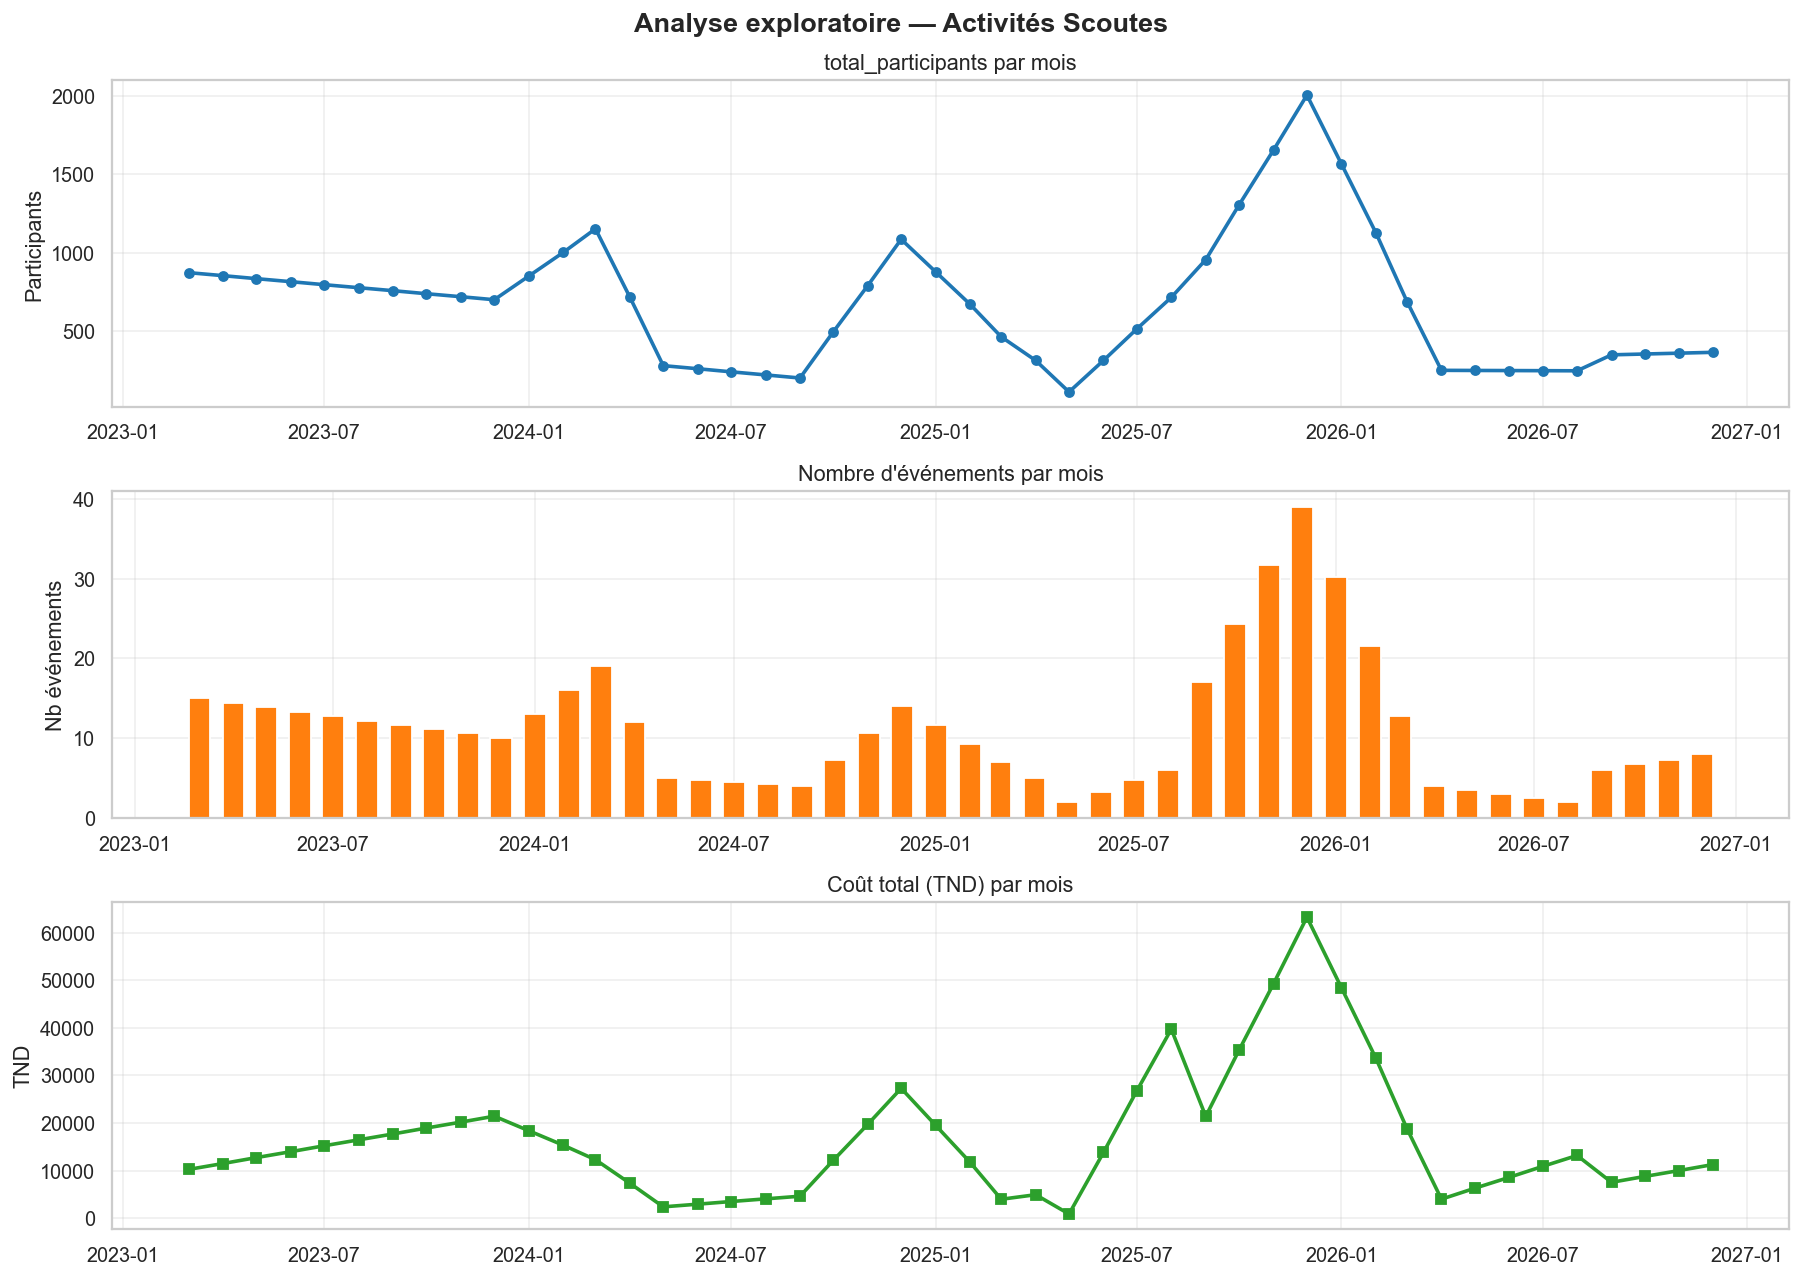

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Analyse exploratoire — Activités Scoutes", fontsize=15, fontweight="bold")

axes[0].plot(y.index, y.values, color="#1f77b4", linewidth=2, marker="o", markersize=5)
axes[0].set_title(f"{TARGET} par mois")
axes[0].set_ylabel("Participants")
axes[0].grid(alpha=0.3)

axes[1].bar(df_ts.index, df_ts["nb_events"], color="#ff7f0e", width=20)
axes[1].set_title("Nombre d'événements par mois")
axes[1].set_ylabel("Nb événements")
axes[1].grid(alpha=0.3)

axes[2].plot(df_ts.index, df_ts["total_cost_TND"], color="#2ca02c",
             linewidth=2, marker="s", markersize=5)
axes[2].set_title("Coût total (TND) par mois")
axes[2].set_ylabel("TND")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploration.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Décomposition de la Série Temporelle

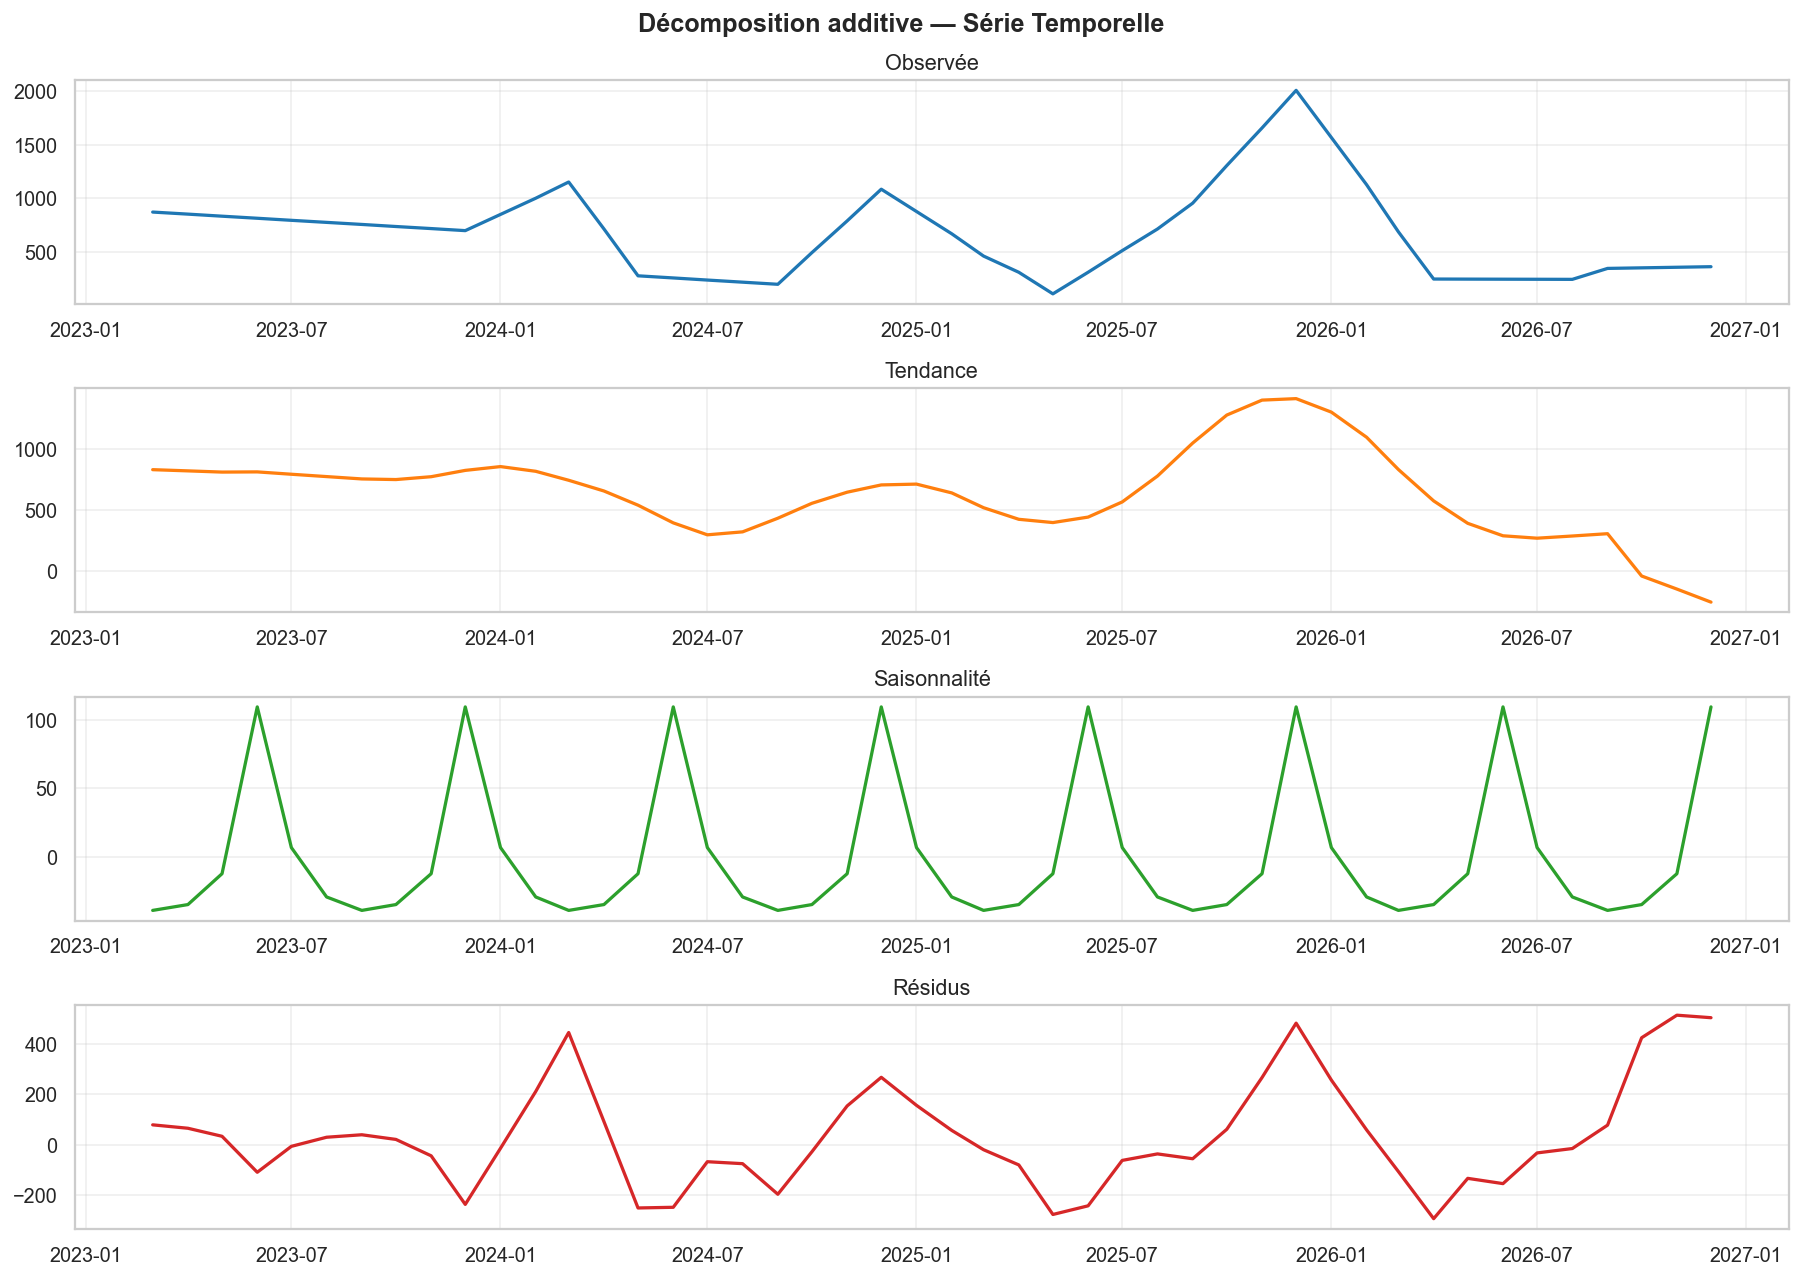

In [30]:
period = min(6, len(y) // 2)
decomp = seasonal_decompose(y, model="additive", period=period, extrapolate_trend="freq")

fig2, axes2 = plt.subplots(4, 1, figsize=(14, 10))
fig2.suptitle("Décomposition additive — Série Temporelle", fontsize=14, fontweight="bold")

components = {
    "Observée":     decomp.observed,
    "Tendance":     decomp.trend,
    "Saisonnalité": decomp.seasonal,
    "Résidus":      decomp.resid,
}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for ax, (title, comp), col in zip(axes2, components.items(), colors):
    ax.plot(comp.index, comp.values, color=col, linewidth=1.8)
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Autocorrélation (ACF & PACF)

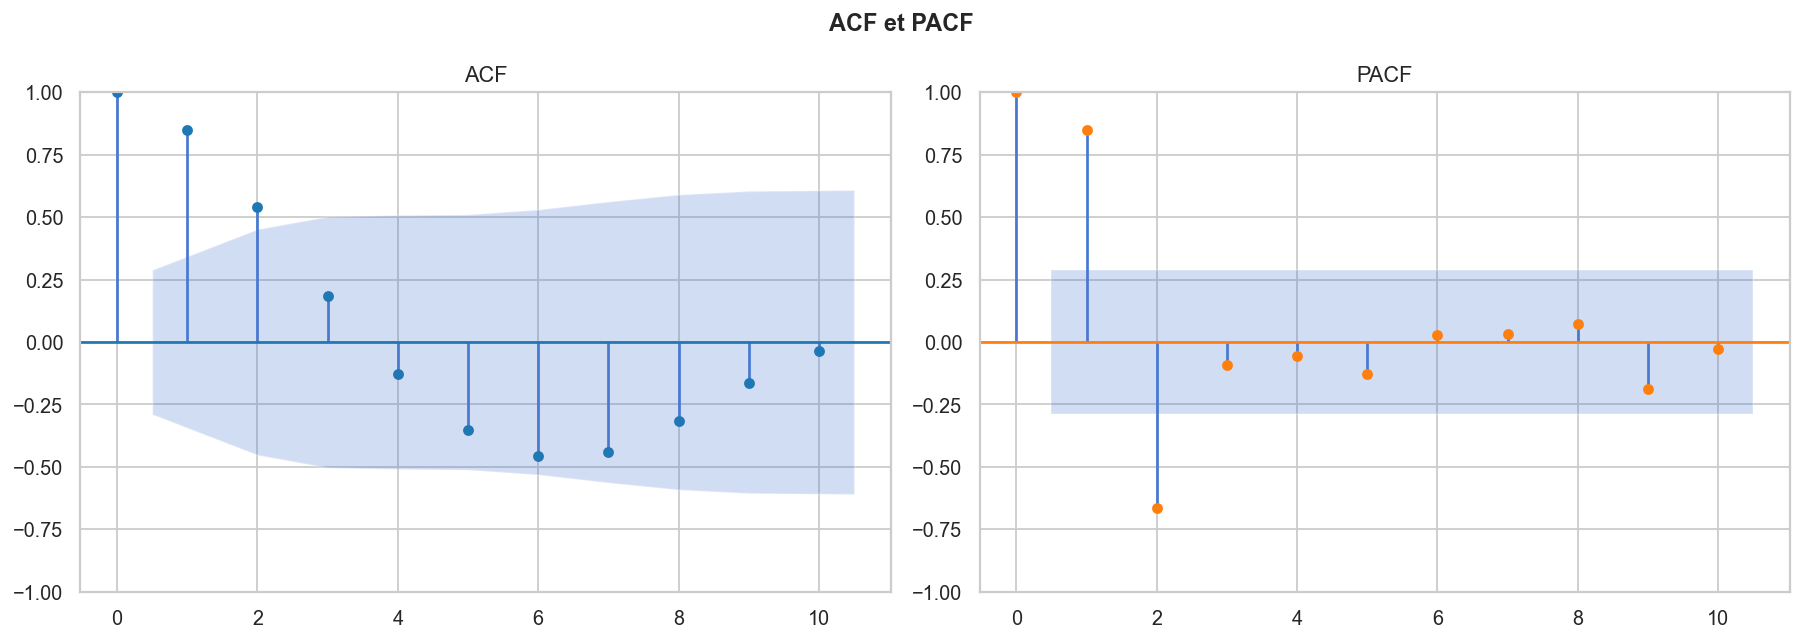

In [31]:
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle("ACF et PACF", fontsize=13, fontweight="bold")

n_lags = min(10, len(y) // 2 - 1)
plot_acf(y,  lags=n_lags, ax=ax1, title="ACF",  color="#1f77b4")
plot_pacf(y, lags=n_lags, ax=ax2, title="PACF", color="#ff7f0e", method="ywm")

plt.tight_layout()
plt.savefig("03_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Tests de Stationnarité (ADF + KPSS)

In [32]:
def test_stationarity(series, name="Série"):
    """Effectue les tests ADF et KPSS et affiche un résumé."""
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")

    # ── Test ADF ──────────────────────────────────────────────
    adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(series.dropna(), autolag="AIC")
    print(f"  ADF  Statistique : {adf_stat:.4f}")
    print(f"  ADF  p-valeur    : {adf_p:.4f}  (lags={adf_lags})")
    for level, val in adf_crit.items():
        print(f"       Critique {level}  : {val:.4f}")
    adf_ok = adf_p < 0.05
    print(f"  → ADF  : {'✅ Stationnaire (p<0.05)' if adf_ok else '❌ Non-stationnaire (p≥0.05)'}")

    # ── Test KPSS ─────────────────────────────────────────────
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"\n  KPSS Statistique : {kpss_stat:.4f}")
    print(f"  KPSS p-valeur    : {kpss_p:.4f}  (lags={kpss_lags})")
    kpss_ok = kpss_p > 0.05
    print(f"  → KPSS : {'✅ Stationnaire (p>0.05)' if kpss_ok else '❌ Non-stationnaire (p≤0.05)'}")

    # ── Conclusion ────────────────────────────────────────────
    if adf_ok and kpss_ok:
        conclusion = "✅ SÉRIE STATIONNAIRE"
    elif not adf_ok and not kpss_ok:
        conclusion = "❌ NON-STATIONNAIRE → différenciation nécessaire"
    else:
        conclusion = "⚠️  Résultats contradictoires → différenciation recommandée"
    print(f"\n  Conclusion : {conclusion}")
    return adf_ok and kpss_ok

In [33]:
stat_orig = test_stationarity(y, f"{TARGET} — Série originale")
y_diff    = y.diff().dropna()
stat_diff = test_stationarity(y_diff, f"{TARGET} — Différencié 1×")

d_order = 0 if stat_orig else 1
print(f"\n➡️  Ordre de différenciation retenu : d = {d_order}")


──────────────────────────────────────────────────
  total_participants — Série originale
──────────────────────────────────────────────────
  ADF  Statistique : -3.9989
  ADF  p-valeur    : 0.0014  (lags=1)
       Critique 1%  : -3.5886
       Critique 5%  : -2.9299
       Critique 10%  : -2.6032
  → ADF  : ✅ Stationnaire (p<0.05)

  KPSS Statistique : 0.0833
  KPSS p-valeur    : 0.1000  (lags=4)
  → KPSS : ✅ Stationnaire (p>0.05)

  Conclusion : ✅ SÉRIE STATIONNAIRE

──────────────────────────────────────────────────
  total_participants — Différencié 1×
──────────────────────────────────────────────────
  ADF  Statistique : -3.8003
  ADF  p-valeur    : 0.0029  (lags=1)
       Critique 1%  : -3.5925
       Critique 5%  : -2.9315
       Critique 10%  : -2.6041
  → ADF  : ✅ Stationnaire (p<0.05)

  KPSS Statistique : 0.0423
  KPSS p-valeur    : 0.1000  (lags=3)
  → KPSS : ✅ Stationnaire (p>0.05)

  Conclusion : ✅ SÉRIE STATIONNAIRE

➡️  Ordre de différenciation retenu : d = 0


## 6. Split Train / Test

Train : 37 points  (2023-03-01 → 2026-03-01)
Test  : 9  points  (2026-04-01  → 2026-12-01)


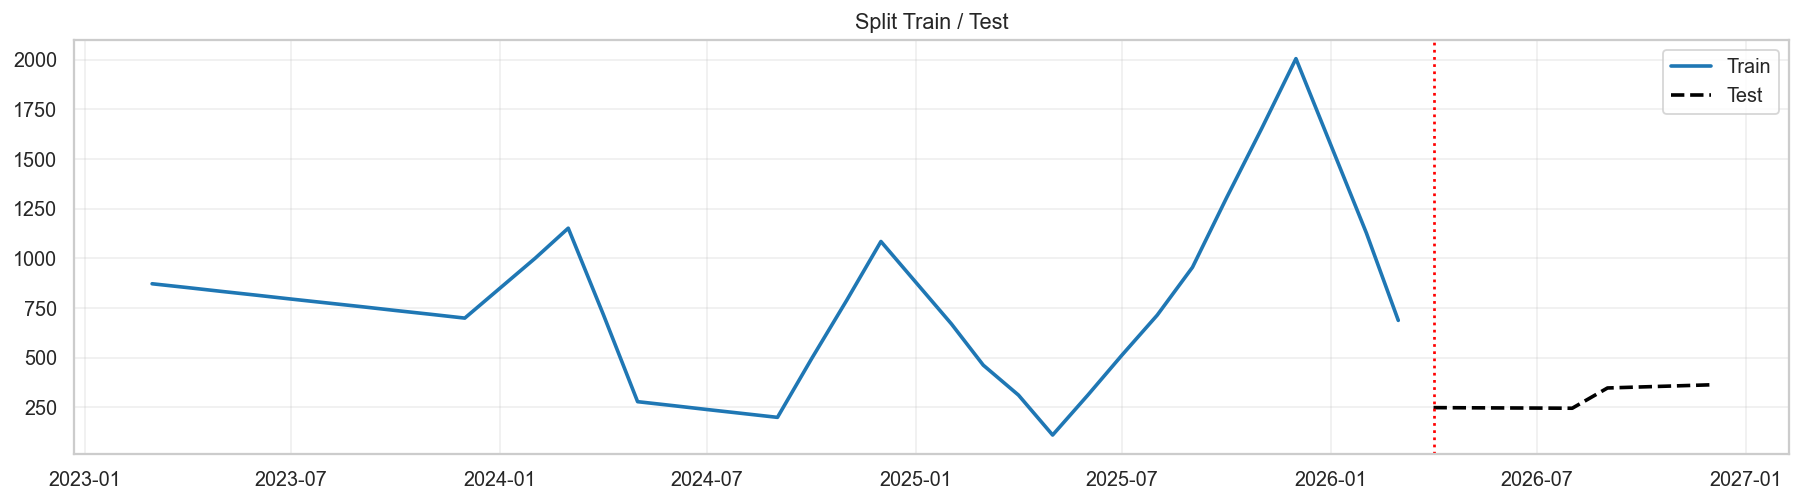

In [34]:
TEST_SIZE = max(2, int(len(y) * 0.20))
train = y.iloc[:-TEST_SIZE]
test  = y.iloc[-TEST_SIZE:]

print(f"Train : {len(train)} points  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test  : {len(test)}  points  ({test.index[0].date()}  → {test.index[-1].date()})")

# Visualisation du split
fig_s, ax_s = plt.subplots(figsize=(14, 4))
ax_s.plot(train.index, train.values, label="Train", color="#1f77b4", linewidth=2)
ax_s.plot(test.index,  test.values,  label="Test",  color="black",   linewidth=2, linestyle="--")
ax_s.axvline(test.index[0], color="red", linestyle=":", linewidth=1.5)
ax_s.set_title("Split Train / Test")
ax_s.legend()
ax_s.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Fonctions d'Évaluation

In [35]:
def compute_metrics(y_true, y_pred, model_name=""):
    """Calcule MAE, RMSE, MAPE."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    if model_name:
        print(f"  {model_name:<12}  MAE = {mae:8.2f}   RMSE = {rmse:8.2f}   MAPE = {mape:6.2f}%")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

results = {}   # stockage des métriques
palette = {"ARIMA": "#e74c3c", "SARIMA": "#2ecc71", "Prophet": "#9b59b6"}
print("Fonctions d'évaluation prêtes ✅")

Fonctions d'évaluation prêtes ✅


## 8. Modèle 1 — ARIMA

Auto-sélection des paramètres (p, d, q) par minimisation de l'AIC.

In [36]:
def grid_search_arima(train_data, d, max_p=3, max_q=3):
    """Recherche en grille pour ARIMA."""
    best_aic, best_order = np.inf, (1, d, 1)
    for p, q in itertools.product(range(max_p + 1), range(max_q + 1)):
        try:
            m = ARIMA(train_data, order=(p, d, q)).fit()
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, d, q)
        except Exception:
            continue
    return best_order, best_aic

arima_order, arima_aic = grid_search_arima(train, d=d_order)
print(f"Meilleur ARIMA : {arima_order}   (AIC = {arima_aic:.2f})")

Meilleur ARIMA : (2, 0, 0)   (AIC = 491.34)


In [37]:
arima_model  = ARIMA(train, order=arima_order).fit()
arima_pred   = arima_model.forecast(steps=TEST_SIZE)
arima_future = arima_model.forecast(steps=6)

print(arima_model.summary().tables[0])
print("\nMétriques sur le test :")
results["ARIMA"] = compute_metrics(test, arima_pred, "ARIMA")

                               SARIMAX Results                                
Dep. Variable:     total_participants   No. Observations:                   37
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -241.668
Date:                Mon, 13 Apr 2026   AIC                            491.337
Time:                        22:00:59   BIC                            497.781
Sample:                    03-01-2023   HQIC                           493.609
                         - 03-01-2026                                         
Covariance Type:                  opg                                         

Métriques sur le test :
  ARIMA         MAE =   329.87   RMSE =   381.03   MAPE = 105.75%


## 9. Modèle 2 — SARIMA

Modèle saisonnier avec période **S = 6 mois** (pics mars + décembre).

In [38]:
S = 6   # saisonnalité semestrielle

def grid_search_sarima(train_data, d, s, max_p=2, max_q=2, max_P=1, max_Q=1):
    """Recherche en grille pour SARIMA."""
    best_aic, best_order = np.inf, ((1, d, 1), (1, 0, 1, s))
    for p, q, P, Q in itertools.product(
        range(max_p + 1), range(max_q + 1),
        range(max_P + 1), range(max_Q + 1)
    ):
        try:
            m = SARIMAX(
                train_data,
                order=(p, d, q),
                seasonal_order=(P, 0, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
            if m.aic < best_aic:
                best_aic, best_order = m.aic, ((p, d, q), (P, 0, Q, s))
        except Exception:
            continue
    return best_order, best_aic

sarima_orders, sarima_aic = grid_search_sarima(train, d=d_order, s=S)
print(f"Meilleur SARIMA : order={sarima_orders[0]}  seasonal={sarima_orders[1]}  (AIC = {sarima_aic:.2f})")

Meilleur SARIMA : order=(1, 0, 2)  seasonal=(1, 0, 1, 6)  (AIC = 387.85)


In [39]:
sarima_model  = SARIMAX(
    train,
    order=sarima_orders[0],
    seasonal_order=sarima_orders[1],
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

sarima_pred   = sarima_model.forecast(steps=TEST_SIZE)
sarima_future = sarima_model.forecast(steps=6)

print("Métriques sur le test :")
results["SARIMA"] = compute_metrics(test, sarima_pred, "SARIMA")

Métriques sur le test :
  SARIMA        MAE =   185.21   RMSE =   219.92   MAPE =  61.02%


## 10. Modèle 3 — Prophet (Facebook / Meta)

Modèle de prévision basé sur la décomposition de tendances et saisonnalités multiples.

22:01:03 - cmdstanpy - INFO - Chain [1] start processing
22:01:04 - cmdstanpy - INFO - Chain [1] done processing


Métriques sur le test :
  Prophet       MAE =  1138.57   RMSE =  1187.45   MAPE = 381.46%


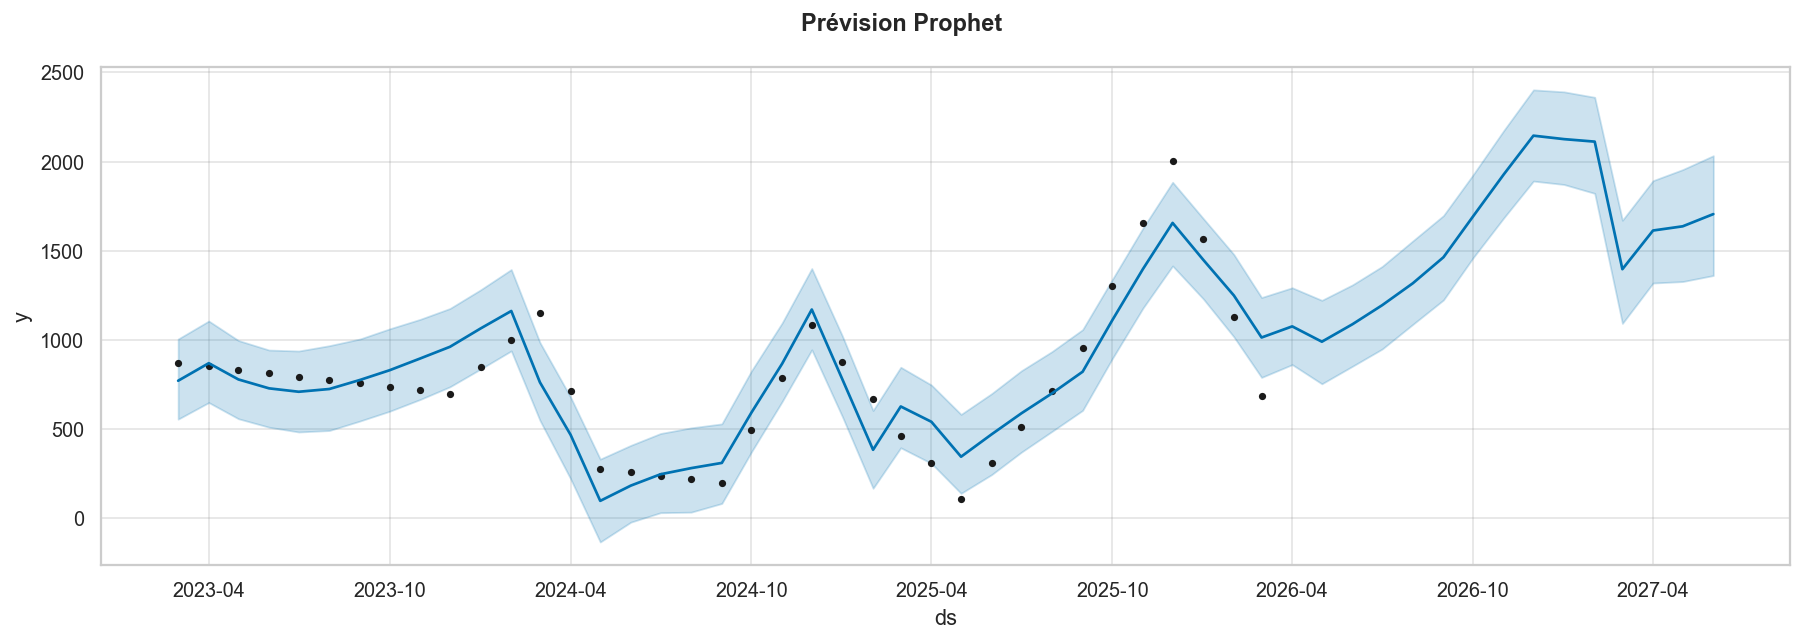

In [40]:
if PROPHET_AVAILABLE:
    df_prophet = pd.DataFrame({"ds": train.index, "y": train.values}).reset_index(drop=True)

    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.3,
        seasonality_mode="additive",
    )
    prophet_model.fit(df_prophet)

    future_dates  = prophet_model.make_future_dataframe(periods=TEST_SIZE + 6, freq="MS")
    forecast_full = prophet_model.predict(future_dates)

    prophet_pred   = forecast_full.set_index("ds")["yhat"].loc[test.index]
    prophet_future = forecast_full.set_index("ds")["yhat"].iloc[-6:]

    print("Métriques sur le test :")
    results["Prophet"] = compute_metrics(test, prophet_pred, "Prophet")

    # Graphique interne Prophet
    fig_p = prophet_model.plot(forecast_full, figsize=(14, 5))
    fig_p.suptitle("Prévision Prophet", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Prophet non disponible — modèle ignoré.")

## 11. Comparaison des Modèles

In [41]:
metrics_df = pd.DataFrame(results).T.sort_values("MAPE")
best_model = metrics_df["MAPE"].idxmin()

print(f"{'Modèle':<12} {'MAE':>10} {'RMSE':>10} {'MAPE %':>10}")
print("─" * 45)
for model, row in metrics_df.iterrows():
    star = " 🏆" if model == best_model else ""
    print(f"{model:<12} {row['MAE']:>10.2f} {row['RMSE']:>10.2f} {row['MAPE']:>10.2f}{star}")

print(f"\n🏆 Meilleur modèle (MAPE minimum) : {best_model}")
metrics_df

Modèle              MAE       RMSE     MAPE %
─────────────────────────────────────────────
SARIMA           185.21     219.92      61.02 🏆
ARIMA            329.87     381.03     105.75
Prophet         1138.57    1187.45     381.46

🏆 Meilleur modèle (MAPE minimum) : SARIMA


,MAE,RMSE,MAPE
SARIMA,185.209332,219.920901,61.022793
ARIMA,329.873329,381.030773,105.753740
Prophet,1138.572482,1187.445252,381.463953


## 12. Graphiques de Prévision

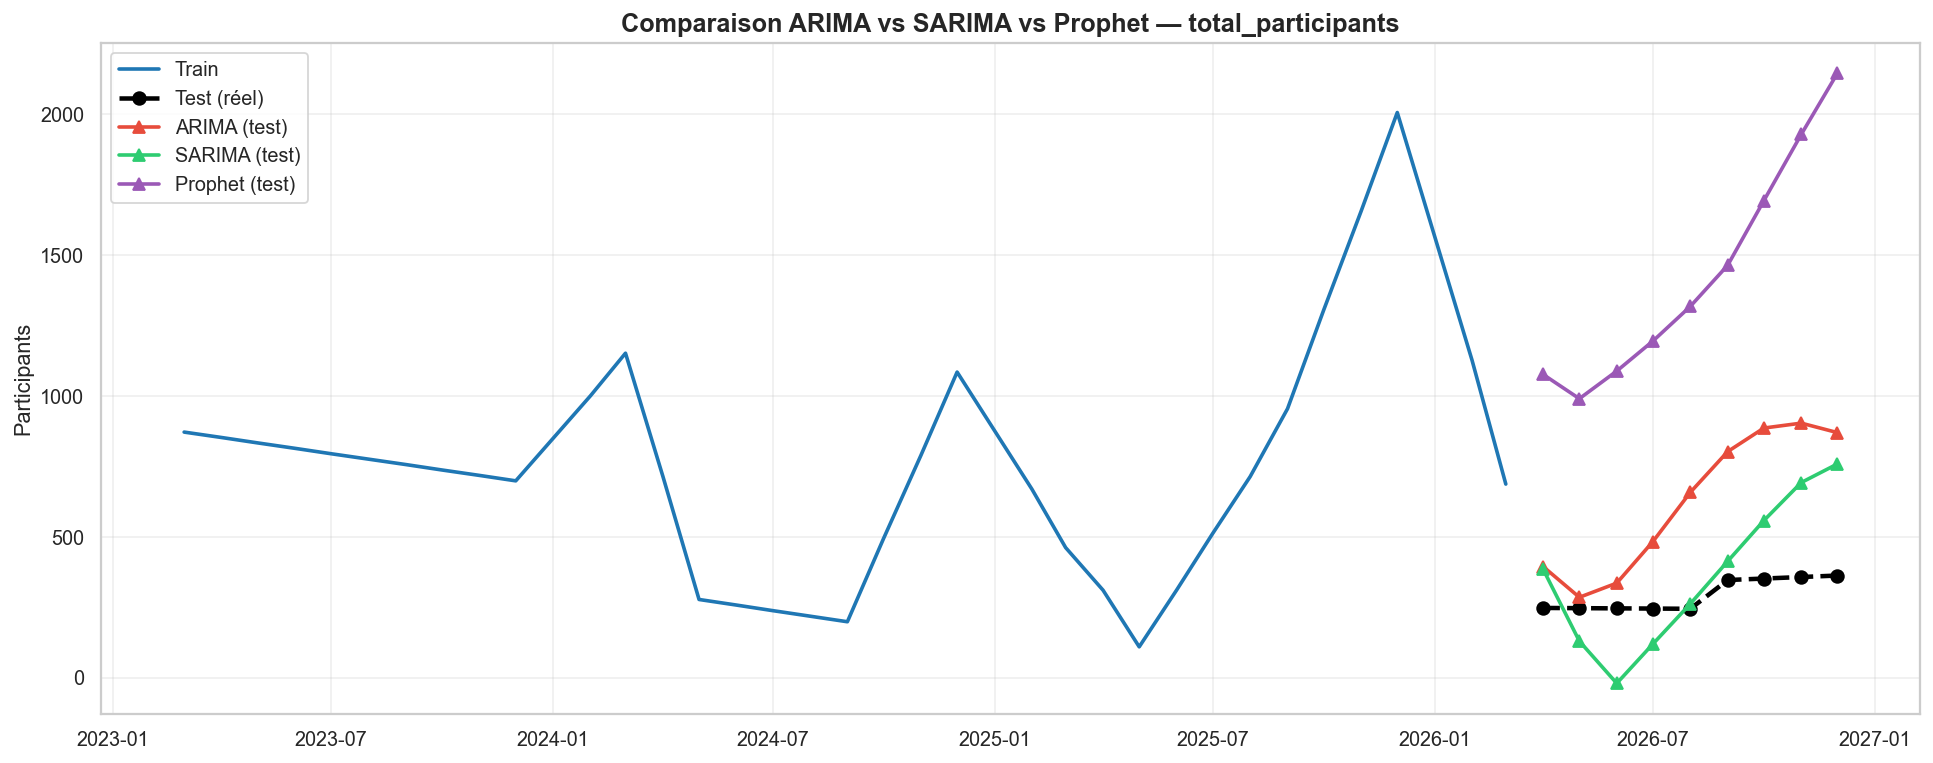

In [42]:
# ── Comparaison test ─────────────────────────────────────────
fig4, ax = plt.subplots(figsize=(15, 6))

ax.plot(train.index, train.values,
        label="Train", color="#1f77b4", linewidth=2)
ax.plot(test.index,  test.values,
        label="Test (réel)", color="black", linewidth=2.5,
        linestyle="--", marker="o", markersize=7)

preds = {"ARIMA": arima_pred, "SARIMA": sarima_pred}
if PROPHET_AVAILABLE:
    preds["Prophet"] = prophet_pred

for name, pred in preds.items():
    ax.plot(test.index, pred.values, label=f"{name} (test)",
            color=palette[name], linewidth=2, marker="^", markersize=7)

ax.set_title(f"Comparaison ARIMA vs SARIMA vs Prophet — {TARGET}",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Participants")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("04_comparaison_modeles.png", dpi=150, bbox_inches="tight")
plt.show()

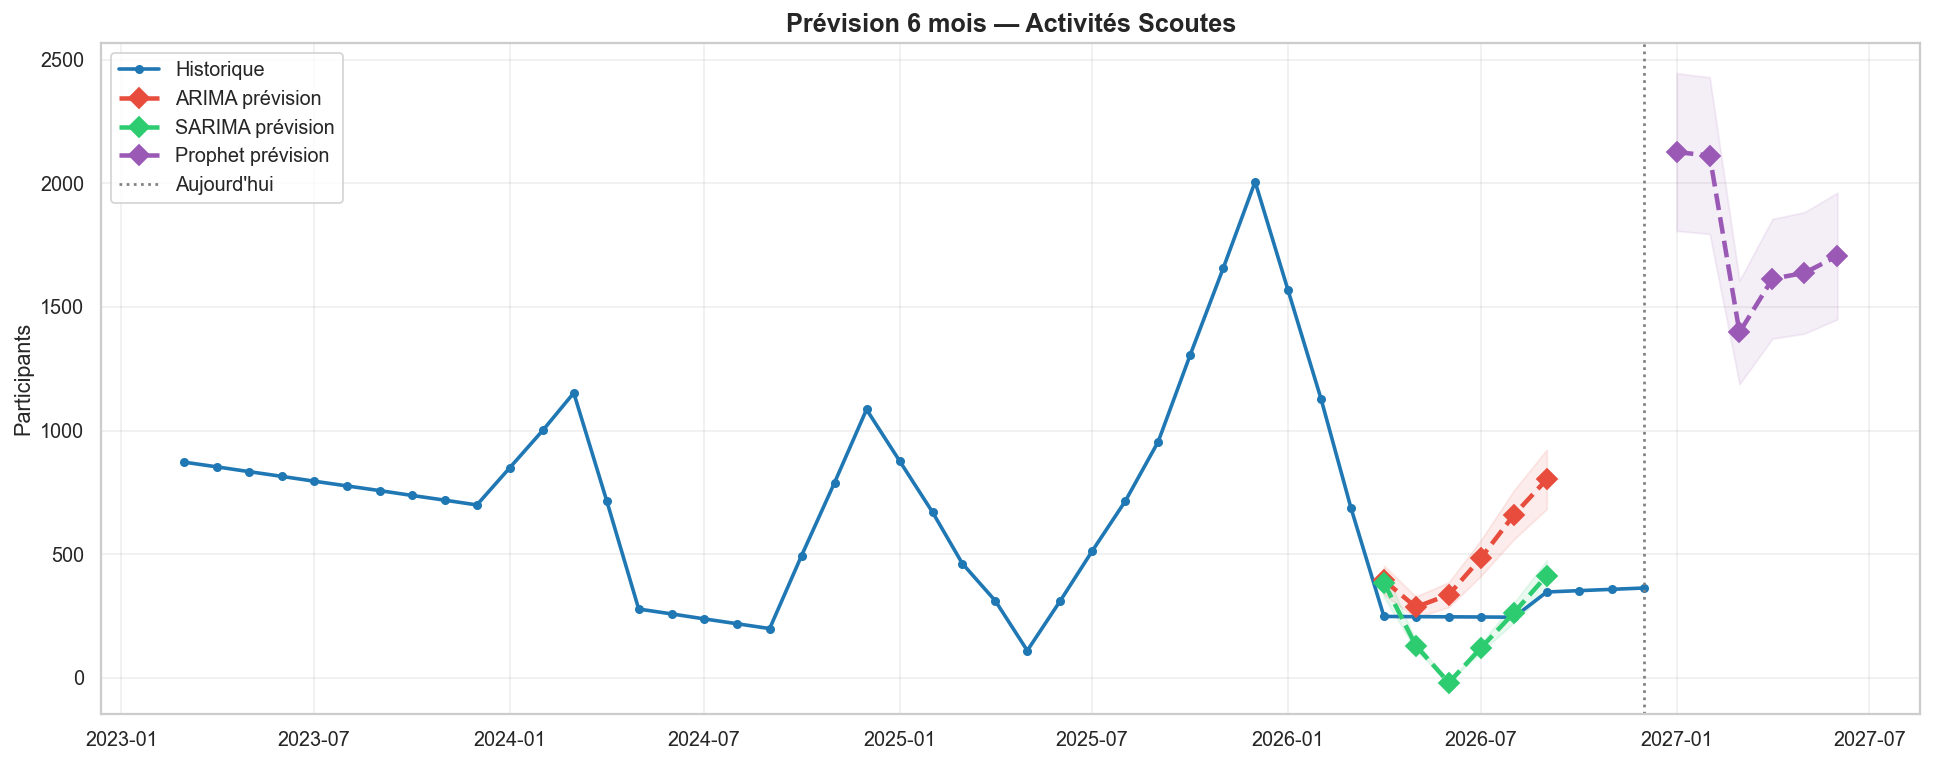

In [43]:
# ── Prévision 6 mois ─────────────────────────────────────────
fig5, ax2 = plt.subplots(figsize=(15, 6))
ax2.plot(y.index, y.values,
         label="Historique", color="#1f77b4", linewidth=2, marker="o", markersize=4)

future_preds = {"ARIMA": arima_future, "SARIMA": sarima_future}
if PROPHET_AVAILABLE:
    future_preds["Prophet"] = prophet_future

for name, fut in future_preds.items():
    ax2.plot(fut.index, fut.values, label=f"{name} prévision",
             color=palette[name], linewidth=2.5, linestyle="--", marker="D", markersize=8)
    ax2.fill_between(fut.index, fut.values * 0.85, fut.values * 1.15,
                     color=palette[name], alpha=0.10)

ax2.axvline(y.index[-1], color="gray", linestyle=":", linewidth=1.5, label="Aujourd'hui")
ax2.set_title("Prévision 6 mois — Activités Scoutes", fontsize=14, fontweight="bold")
ax2.set_ylabel("Participants")
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("05_prevision_future.png", dpi=150, bbox_inches="tight")
plt.show()

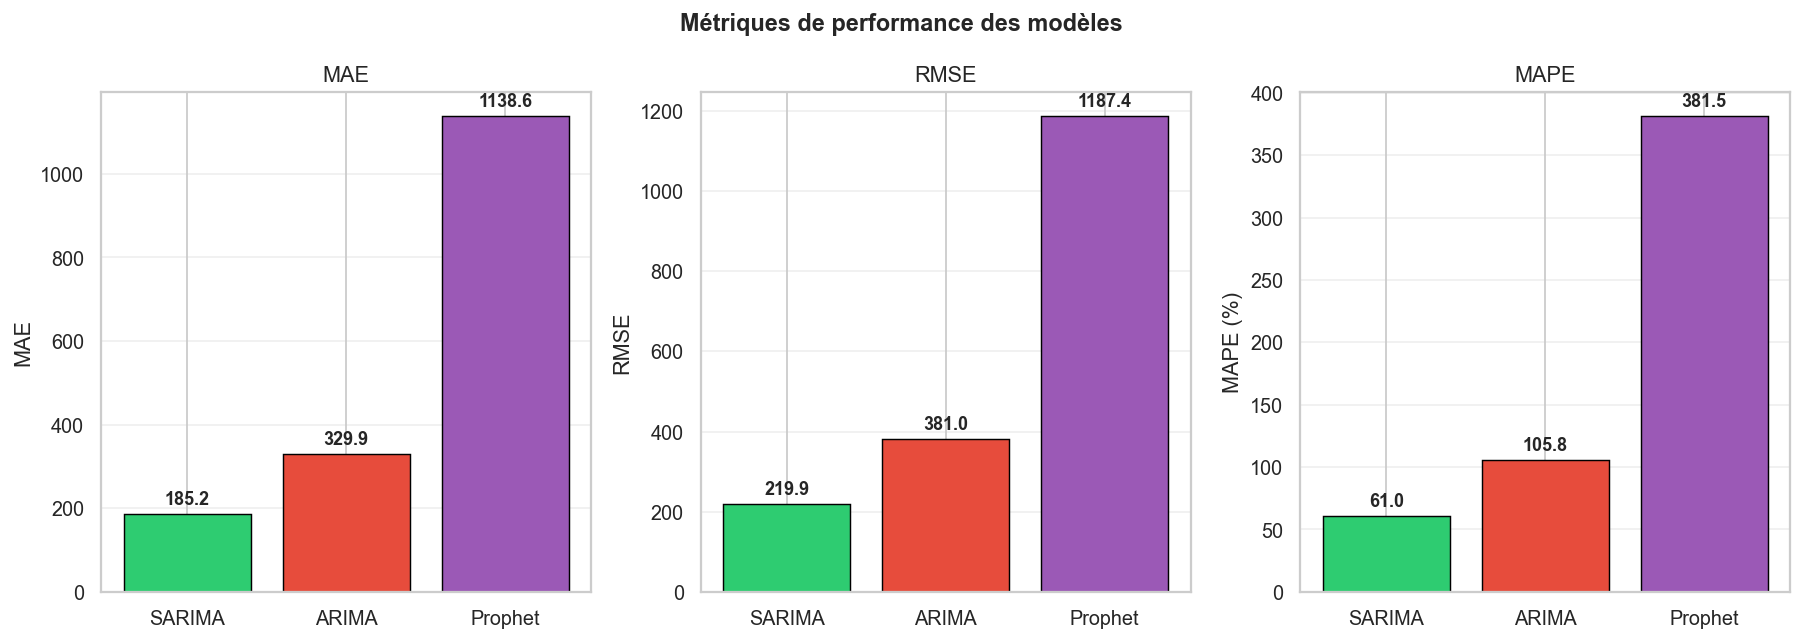

In [44]:
# ── Barres de métriques ──────────────────────────────────────
fig6, axes6 = plt.subplots(1, 3, figsize=(14, 5))
fig6.suptitle("Métriques de performance des modèles", fontsize=13, fontweight="bold")

models = list(metrics_df.index)
colors = [palette.get(m, "#aaa") for m in models]

for ax6, metric in zip(axes6, ["MAE", "RMSE", "MAPE"]):
    bars = ax6.bar(models, metrics_df[metric], color=colors, edgecolor="black", linewidth=0.8)
    ax6.set_title(metric)
    ax6.set_ylabel(metric + (" (%)" if metric == "MAPE" else ""))
    for bar, val in zip(bars, metrics_df[metric]):
        ax6.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + metrics_df[metric].max() * 0.02,
                 f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")
    ax6.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("06_metriques.png", dpi=150, bbox_inches="tight")
plt.show()

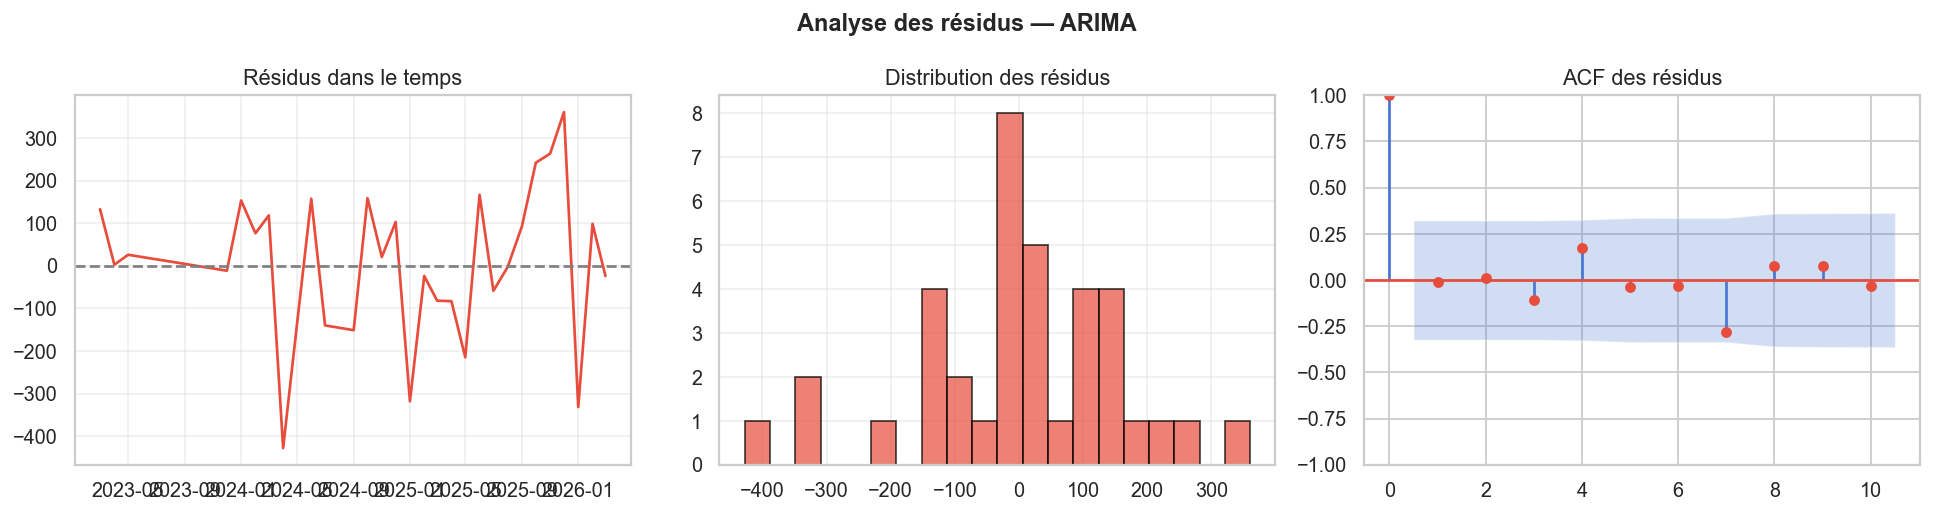

In [45]:
# ── Résidus ARIMA ────────────────────────────────────────────
arima_resid = arima_model.resid
fig7, axes7 = plt.subplots(1, 3, figsize=(15, 4))
fig7.suptitle("Analyse des résidus — ARIMA", fontsize=13, fontweight="bold")

axes7[0].plot(arima_resid.index, arima_resid.values, color="#e74c3c", linewidth=1.5)
axes7[0].axhline(0, linestyle="--", color="gray")
axes7[0].set_title("Résidus dans le temps")
axes7[0].grid(alpha=0.3)

axes7[1].hist(arima_resid.dropna(), bins=20, color="#e74c3c", edgecolor="black", alpha=0.7)
axes7[1].set_title("Distribution des résidus")
axes7[1].grid(alpha=0.3)

plot_acf(arima_resid.dropna(),
         lags=min(10, len(arima_resid)//2 - 1),
         ax=axes7[2], title="ACF des résidus", color="#e74c3c")

plt.tight_layout()
plt.savefig("07_residus_arima.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Export des Résultats

In [46]:
export_rows = []
for name, fut in future_preds.items():
    for dt, val in zip(fut.index, fut.values):
        export_rows.append({"date": dt, "model": name, "predicted_participants": round(val, 1)})

df_export = pd.DataFrame(export_rows).sort_values(["date", "model"])
df_export.to_csv("previsions_scoutes.csv", index=False)
print("✅ previsions_scoutes.csv")

metrics_df.to_csv("metriques_modeles.csv")
print("✅ metriques_modeles.csv")
import pickle

with open("df_export.pkl", "wb") as f:
    pickle.dump(df_export, f)
print("✅ df_export.pkl")


df_export

✅ previsions_scoutes.csv
✅ metriques_modeles.csv
✅ df_export.pkl


,date,model,predicted_participants
0,2026-04-01,ARIMA,394.6
6,2026-04-01,SARIMA,384.8
1,2026-05-01,ARIMA,285.8
7,2026-05-01,SARIMA,130.1
2,2026-06-01,ARIMA,336.1
8,2026-06-01,SARIMA,-19.6
3,2026-07-01,ARIMA,483.7
9,2026-07-01,SARIMA,120.2
4,2026-08-01,ARIMA,658.2
10,2026-08-01,SARIMA,262.7


## 14. Résumé Final

In [47]:
print("=" * 60)
print("  RÉSUMÉ FINAL")
print("=" * 60)
print(f"  Dataset      : {len(df_raw)} événements ({df_raw['year'].min()}–{df_raw['year'].max()})")
print(f"  Série        : {len(y)} points mensuels  |  Cible : {TARGET}")
print(f"  Split        : {len(train)} train / {len(test)} test")
print(f"  Stationnarité originale   : {'OUI' if stat_orig else 'NON'}")
print(f"  Stationnarité différenciée: {'OUI' if stat_diff else 'NON'}")
print(f"  d retenu     : {d_order}")
print()
print(f"  {'Modèle':<12} {'MAE':>9} {'RMSE':>9} {'MAPE %':>9}")
print("  " + "─" * 42)
for model, row in metrics_df.iterrows():
    star = "  🏆" if model == best_model else ""
    print(f"  {model:<12} {row['MAE']:>9.2f} {row['RMSE']:>9.2f} {row['MAPE']:>9.2f}{star}")
print()
print(f"  🏆 Meilleur modèle : {best_model}  (MAPE minimum)")

  RÉSUMÉ FINAL
  Dataset      : 163 événements (2023–2026)
  Série        : 46 points mensuels  |  Cible : total_participants
  Split        : 37 train / 9 test
  Stationnarité originale   : OUI
  Stationnarité différenciée: OUI
  d retenu     : 0

  Modèle             MAE      RMSE    MAPE %
  ──────────────────────────────────────────
  SARIMA          185.21    219.92     61.02  🏆
  ARIMA           329.87    381.03    105.75
  Prophet        1138.57   1187.45    381.46

  🏆 Meilleur modèle : SARIMA  (MAPE minimum)
